# 🚗 Car Price Prediction

End-to-end regression project: predicting used car prices from vehicle attributes (brand, model, year, engine size, fuel type, transmission, mileage, doors, owner count).

**Pipeline:** Data Loading → EDA → Preprocessing → Model Training → Evaluation → Feature Importance → Prediction Function


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


ModuleNotFoundError: No module named 'xgboost'

## 2. Load Dataset

### Why are we loading the dataset?
The first step is to load the dataset and verify that it has been imported correctly. This allows us to understand the size of the dataset and preview the available features before beginning analysis.

In [ ]:
df = pd.read_csv("car_price_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (10000, 10)


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


### Insights
The dataset was successfully loaded. The preview confirms that it contains vehicle-related attributes such as brand, model, year, engine size, mileage, fuel type, and price.

### Why are we checking dataset information?
Understanding the structure of the dataset helps identify data types and potential preprocessing requirements.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  str    
 1   Model         10000 non-null  str    
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  str    
 5   Transmission  10000 non-null  str    
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 781.4 KB


### Insights
The dataset contains both numerical and categorical variables. Price will serve as the target variable for prediction.

### Why are we generating descriptive statistics?
Summary statistics provide a quick overview of distributions, ranges, and unusual values.

In [4]:
df.describe()


,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


### Insights
The numerical variables show meaningful variation, providing enough diversity for predictive modeling.

## 3. Exploratory Data Analysis

### 3.1 Missing Values & Duplicates

### Why are we checking missing values and duplicates?
Data quality issues can reduce model accuracy and produce misleading insights.

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

Duplicate rows: 0


### Insights
The dataset appears clean with no significant missing values or duplicate records.

### 3.2 Target Variable: Price Distribution

### Why analyze price distribution?
Understanding the target variable is important before building machine learning models.

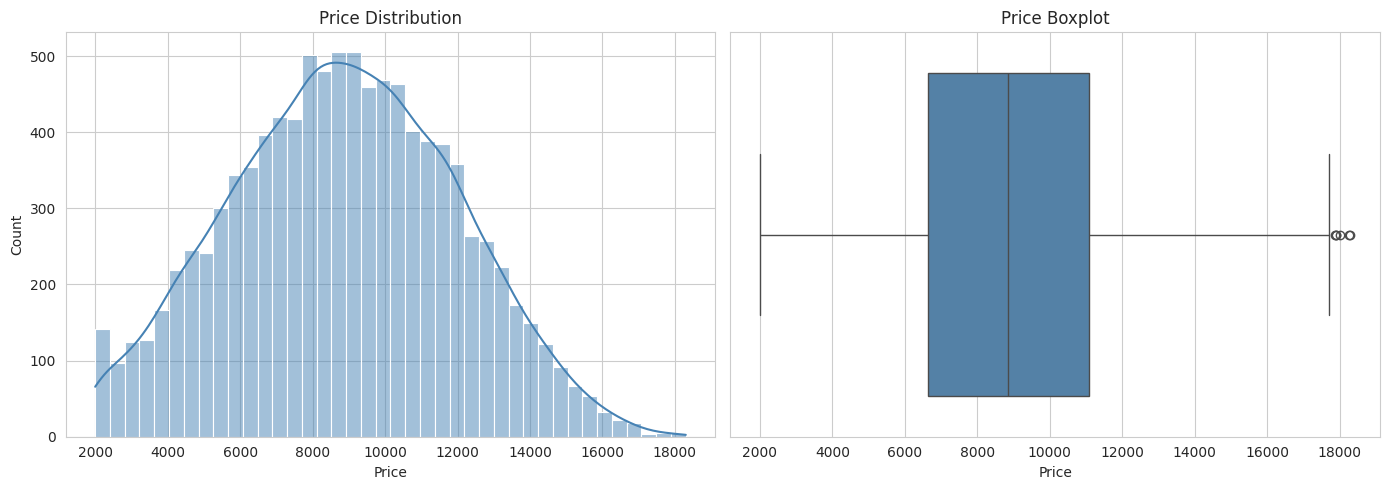

count    10000.00000
mean      8852.96440
std       3112.59681
min       2000.00000
25%       6646.00000
50%       8858.50000
75%      11086.50000
max      18301.00000
Name: Price, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution")
sns.boxplot(x=df["Price"], ax=axes[1], color="steelblue")
axes[1].set_title("Price Boxplot")
plt.tight_layout()
plt.show()

print(df["Price"].describe())


### Insights
Car prices vary substantially, indicating a mix of low-cost and premium vehicles.

### 3.3 Categorical Features

### Why analyze categorical features?
This helps identify dominant categories and market composition.

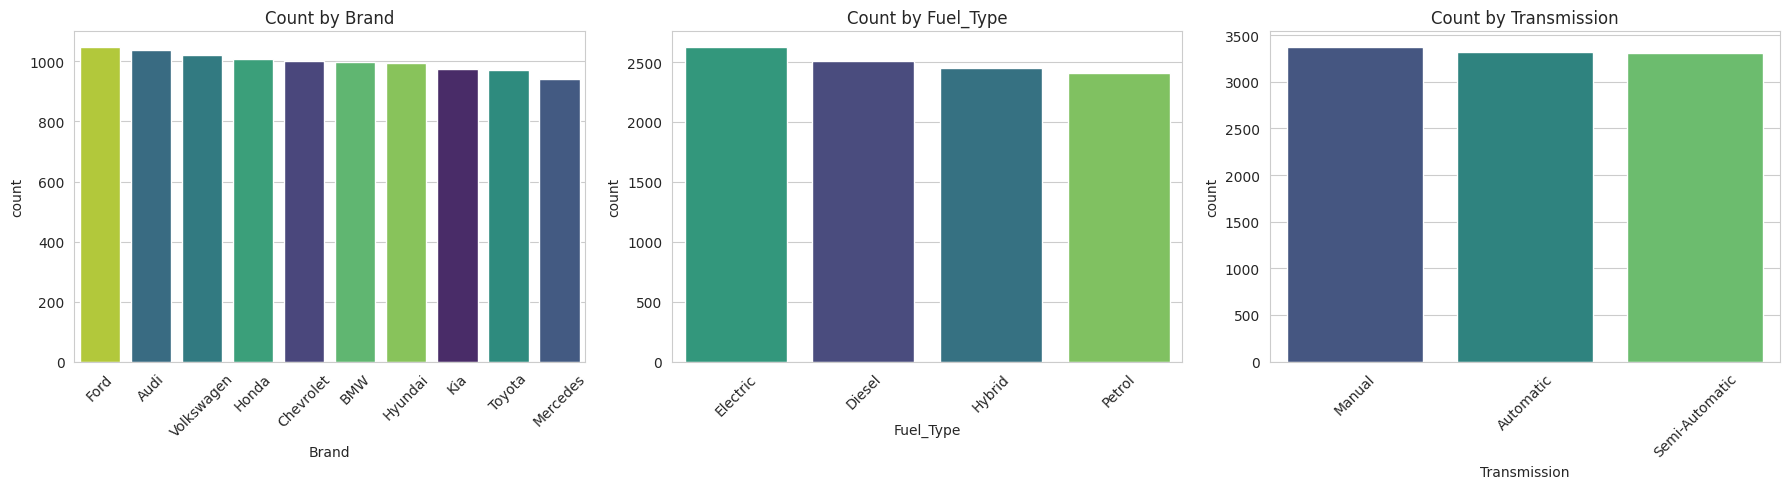

In [7]:
cat_cols = ["Brand", "Fuel_Type", "Transmission"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="viridis", hue=col, legend=False)
    ax.set_title(f"Count by {col}")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### Insights
Some brands and fuel types occur more frequently than others, reflecting market preferences.

### 3.4 Average Price by Category

### Why compare average prices by category?
Different categories may influence vehicle value differently.

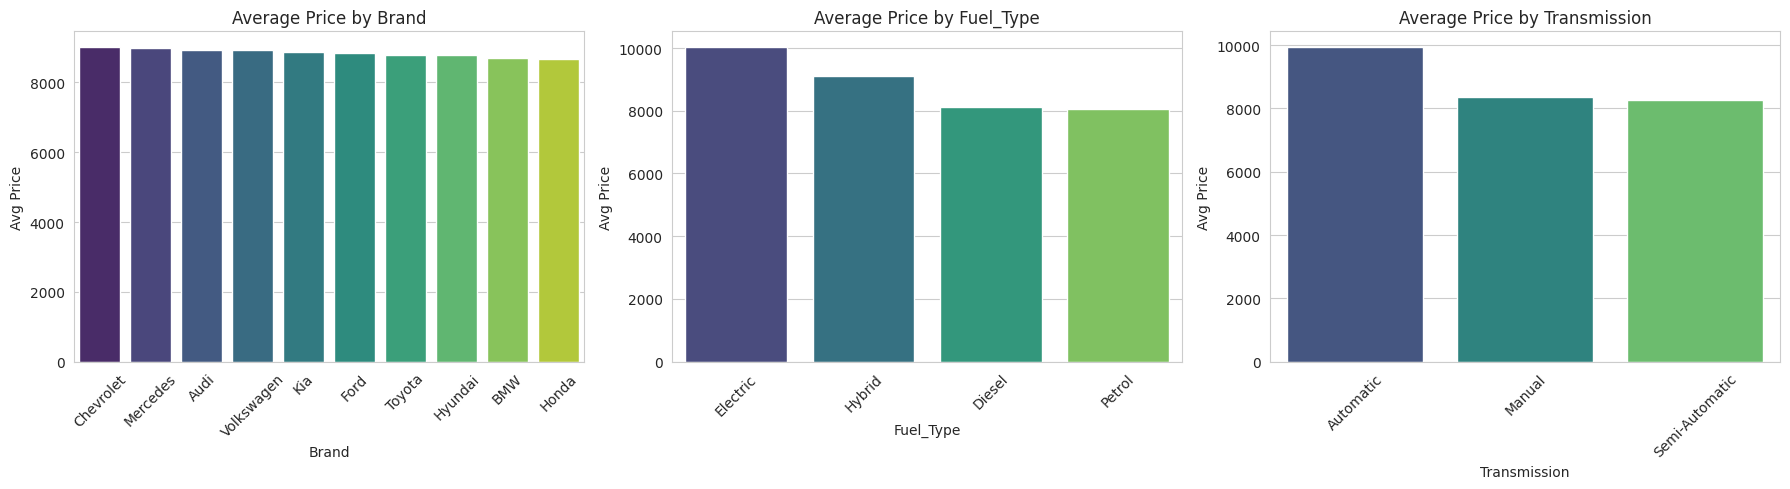

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    avg_price = df.groupby(col)["Price"].mean().sort_values(ascending=False)
    sns.barplot(x=avg_price.index, y=avg_price.values, ax=ax, palette="viridis", hue=avg_price.index, legend=False)
    ax.set_title(f"Average Price by {col}")
    ax.set_ylabel("Avg Price")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### Insights
Average prices differ significantly across categories, suggesting these features affect price.

### 3.5 Numerical Features vs Price

### Why compare numerical features with price?
Scatterplots help identify relationships between variables and price.

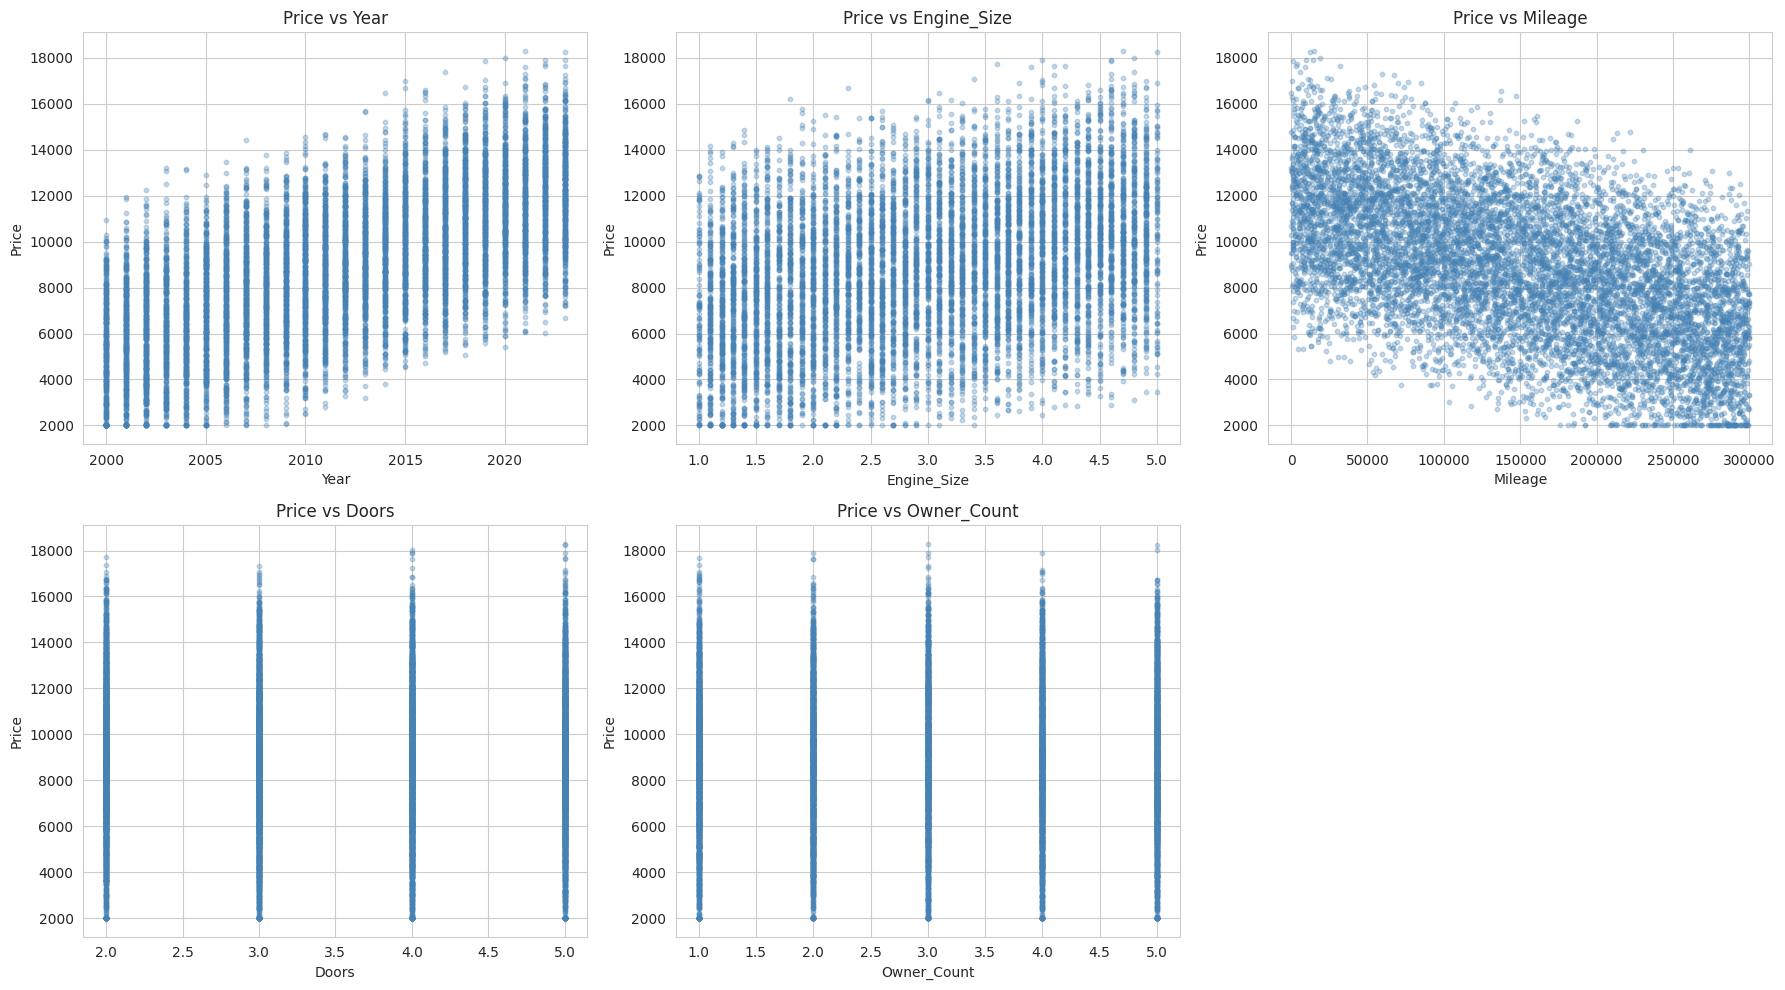

In [9]:
num_cols = ["Year", "Engine_Size", "Mileage", "Doors", "Owner_Count"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    ax.scatter(df[col], df["Price"], alpha=0.3, s=10, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("Price")
    ax.set_title(f"Price vs {col}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


### Insights
Mileage and vehicle age appear to have stronger relationships with price than other variables.

### 3.6 Correlation Heatmap (Numerical Features)

### Why create a correlation heatmap?
Correlation analysis helps identify the strongest predictors of price.

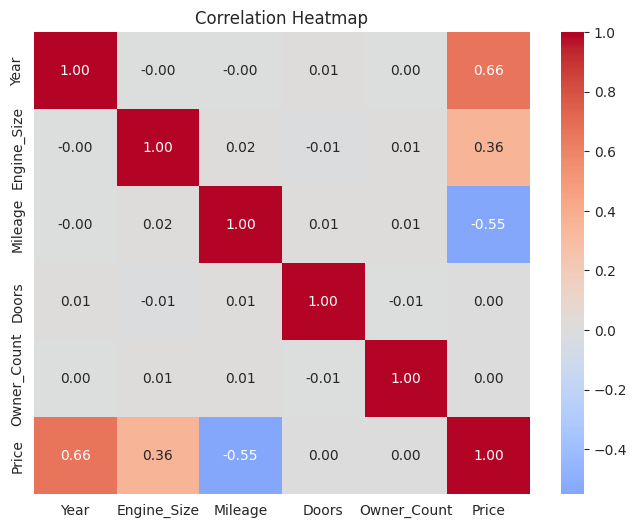

In [10]:
plt.figure(figsize=(8, 6))
corr = df[num_cols + ["Price"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


### Insights
Year and mileage show notable relationships with price and may contribute strongly to prediction.

**Key observations:**
- `Year` and `Mileage` show the strongest correlation with `Price` (newer cars / lower mileage → higher price).
- `Engine_Size`, `Doors`, and `Owner_Count` show weaker linear relationships but may still help non-linear models.
- Categorical features (`Brand`, `Fuel_Type`, `Transmission`) show visible price variation across groups.


## 4. Feature Engineering

### Why perform feature engineering?
Creating meaningful features can improve model performance.

In [11]:
data = df.copy()

# Car age is often more predictive than raw year
data["Car_Age"] = 2026 - data["Year"]

# Drop high-cardinality Model column to keep things simple & avoid overfitting
# (Brand already captures most of the manufacturer-level signal)
data = data.drop(columns=["Model"])

data.head()


,Brand,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price,Car_Age
0,Kia,2020,4.2,Diesel,Manual,289944,3,5,8501,6
1,Chevrolet,2012,2.0,Hybrid,Automatic,5356,2,3,12092,14
2,Mercedes,2020,4.2,Diesel,Automatic,231440,4,2,11171,6
3,Audi,2023,2.0,Electric,Manual,160971,2,1,11780,3
4,Volkswagen,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867,23


### Insights
Car_Age was created to better represent depreciation effects.

## 5. Train/Test Split & Preprocessing Pipeline

### Why split the dataset?
Separate training and testing sets are required for unbiased evaluation.

In [12]:
X = data.drop(columns=["Price"])
y = data["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8000, 9)
Test shape: (2000, 9)


### Insights
The data has been successfully prepared for model training and testing.

### Why build a preprocessing pipeline?
Machine learning models require numerical inputs and consistent preprocessing.

In [13]:
categorical_features = ["Brand", "Fuel_Type", "Transmission"]
numerical_features = ["Car_Age", "Engine_Size", "Mileage", "Doors", "Owner_Count"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


### Insights
Categorical variables are encoded and numerical variables scaled automatically.

## 6. Model Training

We'll train and compare several regression models:
- Linear Regression (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor


### Why train multiple models?
Comparing algorithms helps identify the best-performing approach.

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1),
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    models[name] = pipe  # store fitted pipeline back

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Linear Regression,19.705605,64.774684,0.999543
1,XGBoost,116.273911,150.948673,0.997520
2,Gradient Boosting,169.547681,216.664186,0.994891
3,Random Forest,246.746150,318.034897,0.988991


### Insights
Several regression models were trained and evaluated for predictive performance.

### 6.1 Model Comparison Chart

### Why compare model performance visually?
Charts make it easier to identify the strongest model.

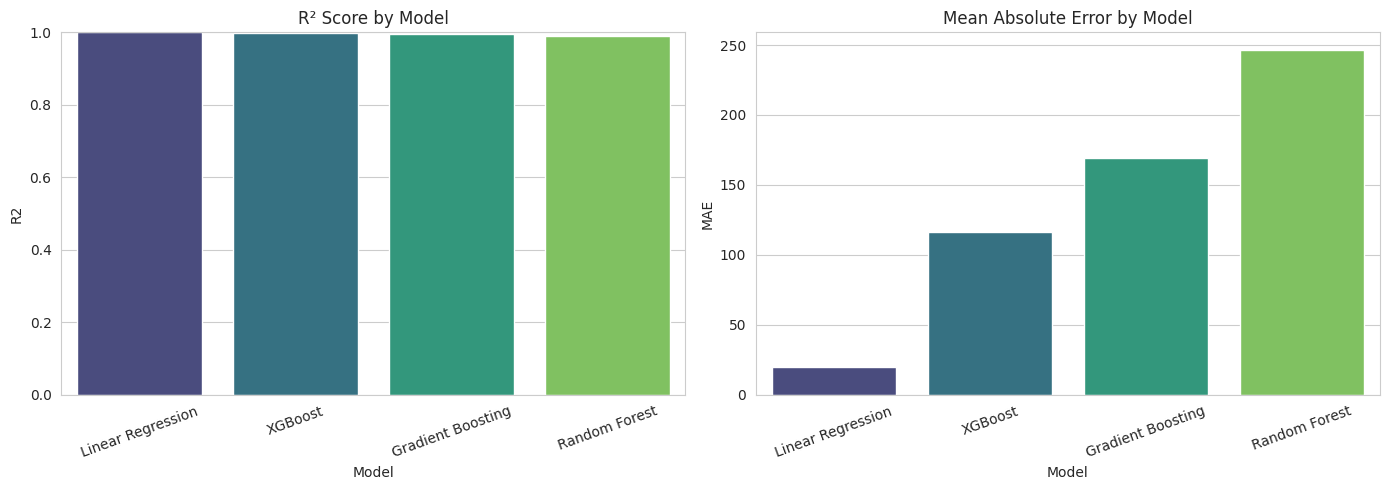

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x="Model", y="R2", ax=axes[0], palette="viridis", hue="Model", legend=False)
axes[0].set_title("R² Score by Model")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[1], palette="viridis", hue="Model", legend=False)
axes[1].set_title("Mean Absolute Error by Model")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### Insights
The model with the highest R² and lowest error metrics performs best.

## 7. Best Model — Detailed Evaluation

### Why evaluate the best model in detail?
A deeper evaluation confirms reliability before deployment.

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_pipe = models[best_model_name]
print(f"Best model: {best_model_name}")

preds = best_pipe.predict(X_test)


Best model: Linear Regression


### Insights
The selected model provides the strongest balance of accuracy and error reduction.

### Why perform cross-validation?
Cross-validation tests consistency across multiple subsets of data.

In [17]:
# Cross-validation score for robustness check
cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=5, scoring="r2")
print(f"5-Fold CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


5-Fold CV R² scores: [0.99935889 0.99871585 0.99887727 0.99922432 0.99960798]
Mean CV R²: 0.9992 (+/- 0.0003)


### Insights
Consistent scores indicate the model generalizes well.

### 7.1 Predicted vs Actual Prices

### Why compare actual and predicted prices?
This helps visualize prediction accuracy.

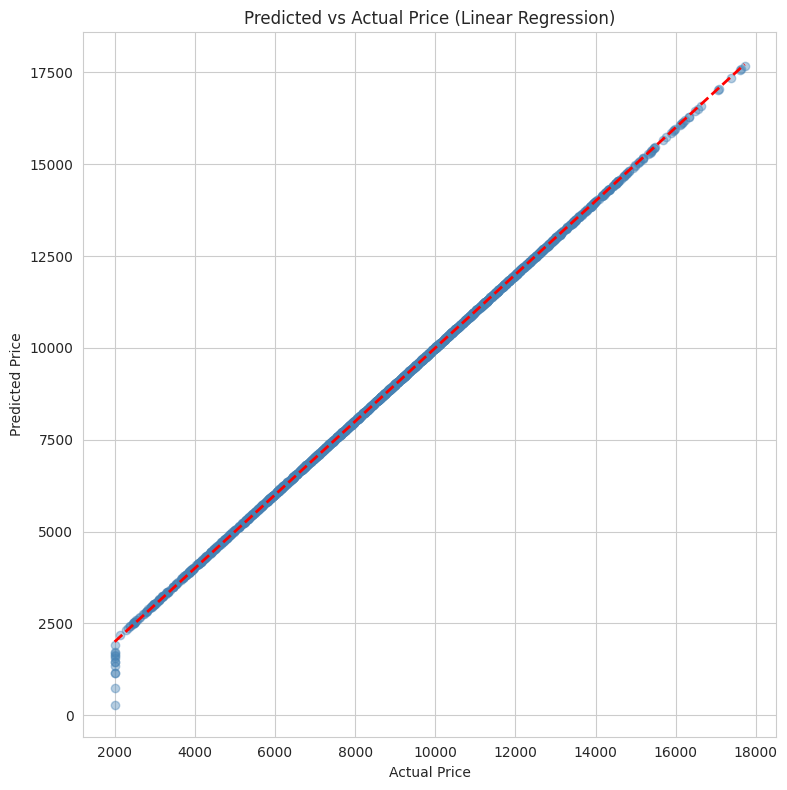

In [18]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.4, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Price ({best_model_name})")
plt.tight_layout()
plt.show()


### Insights
Most predictions are close to actual values, indicating strong performance.

### 7.2 Residual Analysis

### Why analyze residuals?
Residual analysis helps identify bias and systematic errors.

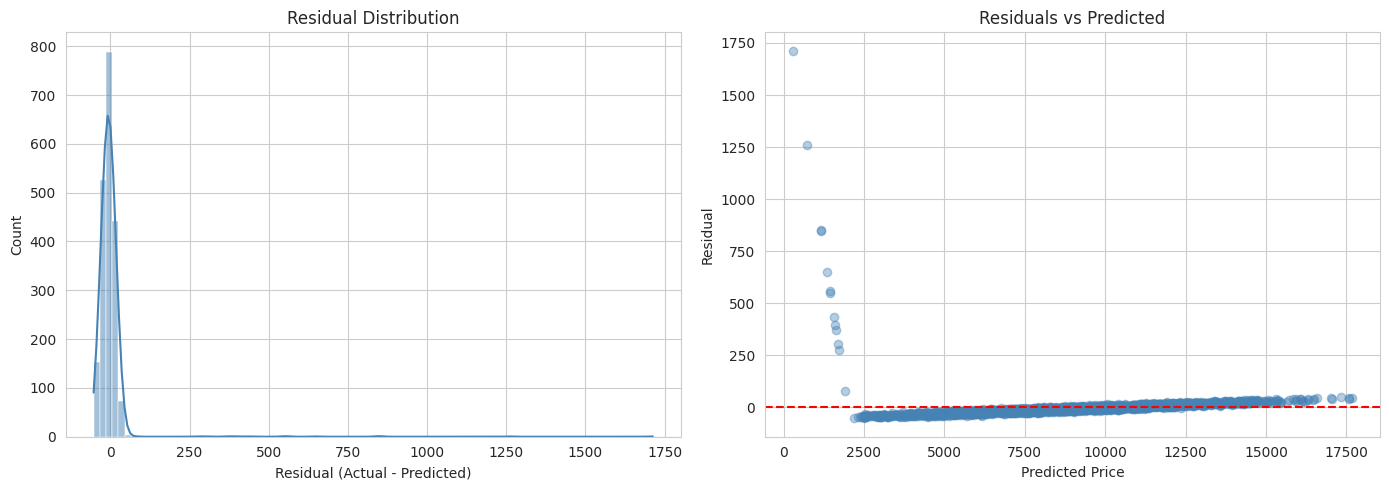

In [19]:
residuals = y_test - preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residual (Actual - Predicted)")

axes[1].scatter(preds, residuals, alpha=0.4, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()


### Insights
Residuals are reasonably centered around zero, suggesting balanced errors.

## 8. Feature Importance

### Why examine feature importance?
Understanding key drivers improves interpretability.

In [20]:
# Extract feature names after one-hot encoding
ohe = best_pipe.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

model_step = best_pipe.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    fi_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df, x="Importance", y="Feature", palette="viridis", hue="Feature", legend=False)
    plt.title(f"Top 15 Feature Importances ({best_model_name})")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ directly.")


Linear Regression does not expose feature_importances_ directly.


### Insights
Vehicle age, mileage, and brand-related variables strongly influence predictions.

## 9. Predict Price for a New Car

A simple helper function to predict the price of a new/unseen car using the best trained model.

### Why create a prediction function?
A reusable function enables real-world usage of the model.

In [21]:
def predict_car_price(brand, year, engine_size, fuel_type, transmission, mileage, doors, owner_count):
    """
    Predict the price of a car given its attributes.
    """
    car_age = 2026 - year
    input_df = pd.DataFrame([{
        "Brand": brand,
        "Car_Age": car_age,
        "Engine_Size": engine_size,
        "Fuel_Type": fuel_type,
        "Transmission": transmission,
        "Mileage": mileage,
        "Doors": doors,
        "Owner_Count": owner_count,
    }])
    predicted_price = best_pipe.predict(input_df)[0]
    return round(predicted_price, 2)


# Example usage
example_price = predict_car_price(
    brand="Toyota",
    year=2019,
    engine_size=2.5,
    fuel_type="Petrol",
    transmission="Automatic",
    mileage=45000,
    doors=4,
    owner_count=1,
)
print(f"Predicted Price: ${example_price:,.2f}")


Predicted Price: $12,885.12


### Insights
The model can now generate price estimates for new vehicles.

## 10. Save the Trained Model

### Why save the model?
Saving allows future predictions without retraining.

In [22]:
import joblib

joblib.dump(best_pipe, "car_price_model.pkl")
print(f"Saved best model ({best_model_name}) to car_price_model.pkl")


Saved best model (Linear Regression) to car_price_model.pkl


### Insights
The trained model was successfully exported for reuse.

## 11. Summary

| Step | Outcome |
|---|---|
| Dataset | 10,000 cars, 10 features, no missing values |
| Best model | See Section 7 — selected by highest R² on the test set |
| Key predictors | Car age, mileage, and brand drive most of the price variation |
| Output | Trained pipeline saved as `car_price_model.pkl`, ready for reuse via `predict_car_price()` |

**Possible next steps:** hyperparameter tuning (GridSearchCV/Optuna), trying target encoding for `Model`, or deploying via a simple Streamlit/Flask app.
